# Segment Length

Units: mm

In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fileName = '/Users/yuntse/data/lartpc_rd/gampix/g4/rad_old/fullgeoanatruth-vd-reduced_g4_0000.root'
treeName = 'edep'

In [3]:
with uproot.open(fileName) as f:
    tree = f[treeName]

    # all branches
    df = tree.arrays( library = "pd" )

print(df.head())
print(df.dtypes)

   event  pdg  trackID  motherID    startE   dE       startX     startY  \
0      0   22     2167         0  0.131562  0.0  3499.631608  34.677207   
1      0   22     2167         0  0.101344  0.0  3480.223416  65.021724   
2      0   22     2167         0  0.083361  0.0  3494.028290  70.815752   
3      0   22     2167         0  0.064258  0.0  3480.022833  59.931349   
4      0   22     2167         0  0.061831  0.0  3476.321906  71.122259   

         startZ        startT         endX       endY          endZ  \
0  10003.538480 -1.813945e+06  3480.223416  65.021724  10004.120732   
1  10004.120732 -1.813945e+06  3494.028290  70.815752  10008.817183   
2  10008.817183 -1.813945e+06  3480.022833  59.931349  10050.210927   
3  10050.210927 -1.813945e+06  3476.321906  71.122259  10033.892365   
4  10033.892365 -1.813944e+06  3488.386360  76.646289  10016.135262   

           endT  
0 -1.813945e+06  
1 -1.813945e+06  
2 -1.813945e+06  
3 -1.813944e+06  
4 -1.813944e+06  
event         

In [6]:
pdgCodes = df.pdg.unique()
pdgCodes

array([        22,         11,        -11, 1000020040,       2112,
       1000200430, 1000180400], dtype=int32)

In [7]:
# create a dataframe for fixing the color code
particleName = np.array([ 'photon', 'electron', 'positron', 'alpha', 'neutron',
                          'Ca43', 'Ar40',
                         ])

pdgDF = pd.DataFrame({ 'pdgCode': pdgCodes, 'name': particleName })

pdgDF

,pdgCode,name
0,22,photon
1,11,electron
2,-11,positron
3,1000020040,alpha
4,2112,neutron
5,1000200430,Ca43
6,1000180400,Ar40


In [8]:
palette = plt.get_cmap("tab10").colors[:8]
colorAll = plt.get_cmap("tab10").colors[8]

# build mapping using pdgDF order
code_to_color = dict(zip(pdgDF["pdgCode"], palette))

# add to pdgDF
pdgDF["color"] = pdgDF["pdgCode"].map(code_to_color)

pdgDF

,pdgCode,name,color
0,22,photon,"(0.12156862745098039, 0.4666666666666667, 0.70..."
1,11,electron,"(1.0, 0.4980392156862745, 0.054901960784313725)"
2,-11,positron,"(0.17254901960784313, 0.6274509803921569, 0.17..."
3,1000020040,alpha,"(0.8392156862745098, 0.15294117647058825, 0.15..."
4,2112,neutron,"(0.5803921568627451, 0.403921568627451, 0.7411..."
5,1000200430,Ca43,"(0.5490196078431373, 0.33725490196078434, 0.29..."
6,1000180400,Ar40,"(0.8901960784313725, 0.4666666666666667, 0.760..."


In [4]:
df['dx'] = np.sqrt( (df.endX - df.startX)**2 + (df.endY - df.startY)**2 + (df.endZ - df.startZ)**2 )

In [5]:
df.dx.min(), df.dx.max()

(0.0, 38469.77312603787)

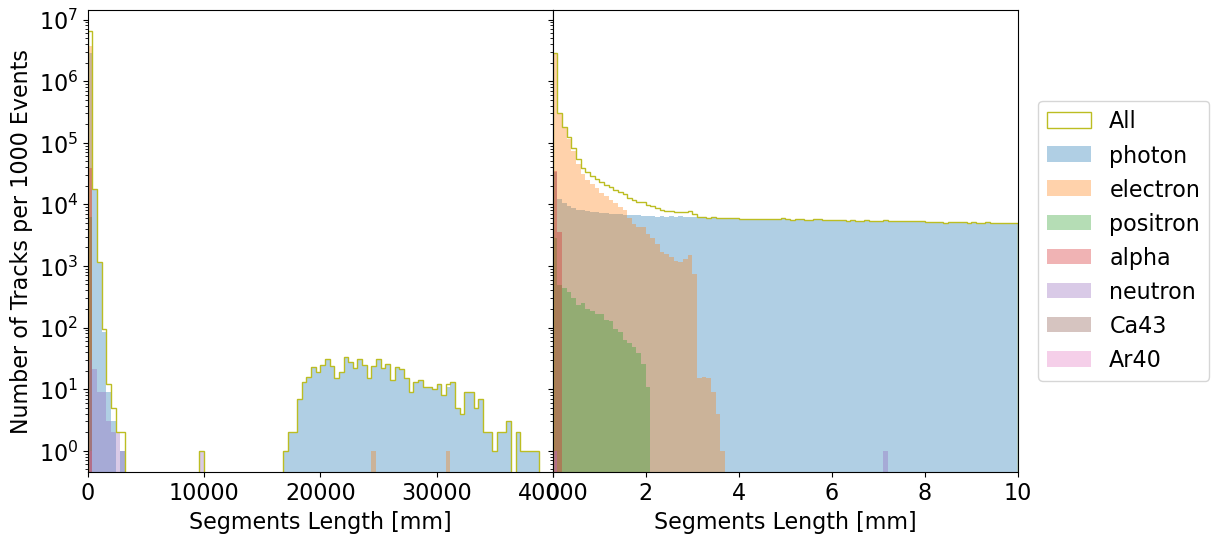

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (12, 6), sharey = True)
fig.subplots_adjust(wspace = 0)

dxBins = [ np.linspace(0., 40000, 101), np.linspace(0., 10, 101) ]
fonts = 16

for i in range(2):
    ax[i].hist(df.dx, bins = dxBins[i], histtype = 'step', label = 'All', color = colorAll)
    for ip in pdgDF.itertuples( index = False ):
        mask = df["pdg"].eq(ip.pdgCode)
        ax[i].hist(df.loc[mask, 'dx'], bins = dxBins[i], histtype = 'stepfilled', alpha = 0.35,
                   color = ip.color, label = ip.name)

    ax[i].set_xlabel('Segments Length [mm]', fontsize = fonts)
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Tracks per 1000 Events', fontsize = fonts)
ax[0].set_xlim([0, 40000])
ax[1].set_xlim([0, 10])
ax[1].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)